In [ ]:
from google.colab import files
uploaded = files.upload()

Off-diagonal error in eigenbasis H: 2.76e-13
  (should be < 1e-6 to validate diagonal assumption)
Energies E_1..E_5: [0.5    1.4998 2.4996 3.4992 4.4987]
  Expected (n+0.5)*hbar*omega: [0.5, 1.5, 2.5, 3.5, 4.5]

CN propagator moduli — min: 1.000000000000000, max: 1.000000000000000
  (should all be exactly 1.0)

VALIDATION ON ONE TEST TRAJECTORY
State type:                  random_superposition
Initial probability P0:      1.000000000000000
Max probability deviation:   7.28e-14  (target < 1e-10)
Initial energy E0:           9.666016
Max energy deviation:        8.35e-14  (target < 1e-8)
Population variance:         6.416789e-29
Max population change:       5.989653e-14
  -> Correct: populations are conserved in the Hamiltonian eigenbasis.

ARCHITECTURE CONSTRAINT VERIFICATION
Verifying: sum_n E_n p_n = E0 at every timestep
(This is what the hard-constraint layer enforces structurally)

Max  |sum_n E_n p_n(t) - E0|:  8.35e-14
Mean |sum_n E_n p_n(t) - E0|:  4.51e-14
This is the numerical 

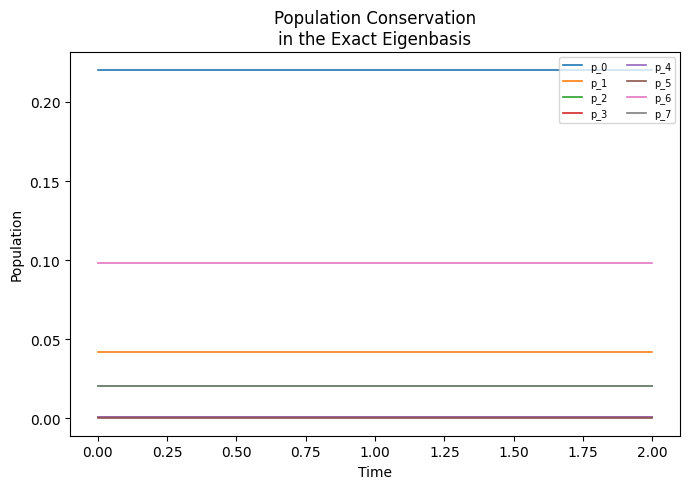

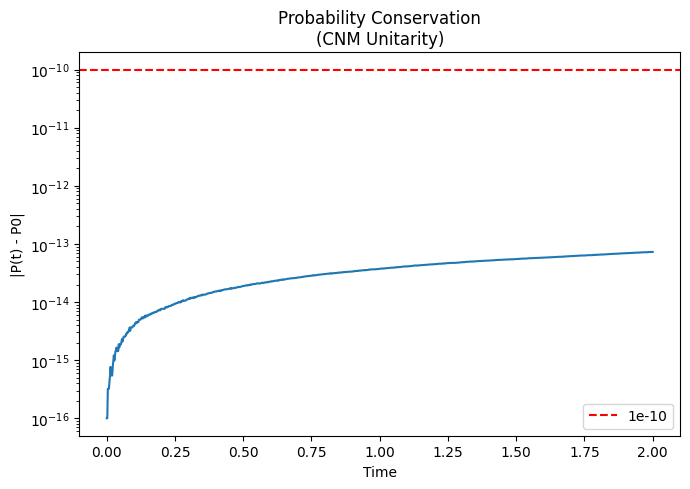

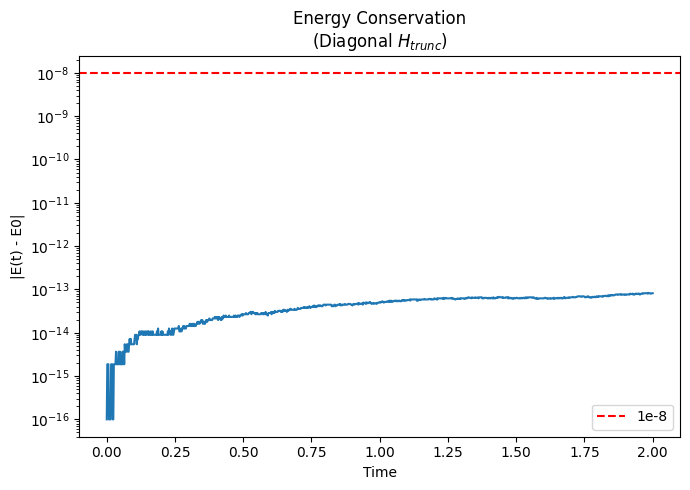

GENERATING FULL DATASET
  Generated 200/1000 states...
  Generated 400/1000 states...
  Generated 600/1000 states...
  Generated 800/1000 states...
  Generated 1000/1000 states...

DATASET CONSTRAINT VERIFICATION
Total samples:               20000
Input shape:                 (20000, 66)  (2*32 + 2 = 66)
Target shape:                (20000, 64)  (2*32 = 64)

Max |P(t) - 1| across dataset:  2.58e-13
Max |E(t) - E0| across dataset: 5.92e-12

Population conservation across dataset:
  Variance of (p_n(t) - p_n(0)):  8.814076e-29
  Max |p_n(t) - p_n(0)|:          2.617906e-13
  -> Correct: populations are conserved in the exact eigenbasis.

State type distribution:
  gaussian_wavepacket: 507 initial states (10140 samples)
  random_superposition: 493 initial states (9860 samples)

E0 distribution across dataset:
  Min E0: 0.5312
  Max E0: 25.3502
  Mean E0: 9.4936
  Std E0:  6.8580
  (E_1 = 0.5000, E_N = 31.7068)

Split sizes (by state, no leakage):
  Train: 14000 samples (700 states)
  Val:

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

DATASET SAVED TO quantum_dataset/
Files:
  X_train.npy, Y_train.npy
  X_val.npy,   Y_val.npy
  X_test.npy,  Y_test.npy
  metadata.csv
  energies.npy   <- E_n for architecture (diagonal H entries)
  H_trunc.npy    <- diag(E_n), the truncated Hamiltonian
  phi.npy        <- eigenvectors on spatial grid
  config.json    <- all hyperparameters

Architecture contract satisfied:
  H_trunc = diag(E_1,...,E_N)  [exact]
  sum_n E_n p_n = E0           [exact]
  P = sum_n p_n = 1            [exact]
  p_n(t) = p_n(0)              [eigenbasis dynamics, verified above]


In [ ]:
"""
Dataset Generator, Harmonic Oscillator in Exact Eigenbasis
Research scope:
  - Closed quantum system
  - Diagonal Hamiltonian in the truncated eigenbasis: H = diag(E_1,...,E_N)
  - Crank-Nicolson Method (CNM) for time evolution
  - Single-step prediction: psi(0) -> psi(t)
  - Hard constraints: <psi|psi> = 1 and <psi|H|psi> = E0 by architecture
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import eigh
from sklearn.model_selection import train_test_split
import os
import random
import zipfile
from google.colab import files

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Physical constants (natural units)
HBAR  = 1.0
MASS  = 1.0
OMEGA = 1.0

# Spatial grid
N_GRID = 512          # grid points
X_MAX  = 8.0          # grid half-width

# Truncated basis size
N_BASIS = 32          # number of eigenstates kept

# Time evolution parameters
DT    = 0.002         # timestep
T_MAX = 2.0           # maximum evolution time

# Dataset size
N_STATES          = 1000   # distinct initial states
N_TIMES_PER_STATE = 20     # target times sampled per state

# STEP 1 — Build spatial grid and finite-difference Hamiltonian
x  = np.linspace(-X_MAX, X_MAX, N_GRID)
dx = x[1] - x[0]

# Second-order Finite Difference Laplacian
main_diag = -2.0 * np.ones(N_GRID)
off_diag  =  1.0 * np.ones(N_GRID - 1)
laplacian = (
    np.diag(main_diag)
    + np.diag(off_diag,  1)
    + np.diag(off_diag, -1)
) / dx**2

kinetic   = -(HBAR**2 / (2.0 * MASS)) * laplacian
potential = np.diag(0.5 * MASS * OMEGA**2 * x**2)

H_position = kinetic + potential   # N_GRID x N_GRID matrix

# STEP 2 — Compute exact eigenbasis (truncated to N_BASIS)
eigenvalues, eigenvectors = eigh(H_position)
energies = eigenvalues[:N_BASIS]          # shape (N_BASIS,)
phi      = eigenvectors[:, :N_BASIS]      # shape (N_GRID, N_BASIS)

# Normalize eigenvectors in continuous sense
for n in range(N_BASIS):
    norm       = np.sqrt(np.sum(np.abs(phi[:, n])**2) * dx)
    phi[:, n] /= norm

# Verify: H in eigenbasis should be diagonal
H_eigen = phi.T @ H_position @ phi * dx     # shape (N_BASIS, N_BASIS)
off_diagonal_error = np.max(
    np.abs(H_eigen - np.diag(np.diag(H_eigen)))
)
print(f"Off-diagonal error in eigenbasis H: {off_diagonal_error:.2e}")
print(f"  (should be < 1e-6 to validate diagonal assumption)")
print(f"Energies E_1..E_5: {energies[:5].round(4)}")
print(f"  Expected (n+0.5)*hbar*omega: {[(n+0.5) for n in range(5)]}")
print()

# Diagonal Hamiltonian
H_trunc = np.diag(energies)   # shape (N_BASIS, N_BASIS), exactly diagonal

# STEP 3 — Crank-Nicolson propagator in the diagonal eigenbasis
alpha = energies * DT / (2.0 * HBAR)           # shape (N_BASIS,)
cn_diag = (1.0 - 1j * alpha) / (1.0 + 1j * alpha)   # shape (N_BASIS,)

# Verify unitarity of propagator
moduli = np.abs(cn_diag)
print(f"CN propagator moduli — min: {moduli.min():.15f}, max: {moduli.max():.15f}")
print(f"  (should all be exactly 1.0)")
print()

def cn_step(c):
    return cn_diag * c

# STEP 4 — Initial state generators

def random_superposition():
    amplitudes = np.random.exponential(scale=1.0, size=N_BASIS)
    phases     = np.random.uniform(-np.pi, np.pi, size=N_BASIS)
    c = amplitudes * np.exp(1j * phases)
    c = c / np.linalg.norm(c)
    return c


def gaussian_wavepacket():
    x0    = np.random.uniform(-2.5, 2.5)
    sigma = np.random.uniform(0.4, 1.2)
    k0    = np.random.uniform(-3.0, 3.0)

    # Build wavepacket on spatial grid
    psi = np.exp(-(x - x0)**2 / (4.0 * sigma**2)) * np.exp(1j * k0 * x)

    # Normalize on grid
    psi = psi / np.sqrt(np.sum(np.abs(psi)**2) * dx)

    # Project onto truncated eigenbasis: c_n = <φ_n|ψ> = ∫ φ_n*(x) ψ(x) dx
    c = phi.conj().T @ psi * dx    # shape (N_BASIS,)

    # Renormalize within truncated subspace
    norm_truncated = np.linalg.norm(c)
    c = c / norm_truncated

    return c


def generate_initial_state():
    if np.random.rand() < 0.5:
        return random_superposition(), "random_superposition"
    else:
        return gaussian_wavepacket(), "gaussian_wavepacket"

# STEP 5 — Physical observables

def compute_probability(c):
    return np.sum(np.abs(c)**2).real


def compute_energy(c):
    return np.sum(energies * np.abs(c)**2).real


def compute_populations(c):
    return np.abs(c)**2

# STEP 6 — Trajectory generator

def generate_trajectory(c0):
    n_steps    = int(T_MAX / DT)
    trajectory = [c0.copy()]
    c          = c0.copy()

    for _ in range(n_steps):
        c = cn_step(c)
        trajectory.append(c.copy())

    trajectory = np.array(trajectory)    # (n_steps+1, N_BASIS)
    times      = np.arange(n_steps + 1) * DT

    return times, trajectory

# STEP 7 — Validation on one test trajectory
print("=" * 60)
print("VALIDATION ON ONE TEST TRAJECTORY")
print("=" * 60)

c0_test, type_test = generate_initial_state()
times_test, trajectory_test = generate_trajectory(c0_test)

probabilities_test    = np.array([compute_probability(c) for c in trajectory_test])
energy_history_test   = np.array([compute_energy(c)      for c in trajectory_test])

P0_test = compute_probability(c0_test)
E0_test = compute_energy(c0_test)

max_prob_dev   = np.max(np.abs(probabilities_test  - P0_test))
max_energy_dev = np.max(np.abs(energy_history_test - E0_test))

print(f"State type:                  {type_test}")
print(f"Initial probability P0:      {P0_test:.15f}")
print(f"Max probability deviation:   {max_prob_dev:.2e}  (target < 1e-10)")
print(f"Initial energy E0:           {E0_test:.6f}")
print(f"Max energy deviation:        {max_energy_dev:.2e}  (target < 1e-8)")

# Population conservation check — expect zero variation in exact eigenbasis
pop_changes    = np.array([
    compute_populations(c) - compute_populations(c0_test)
    for c in trajectory_test
])
pop_variance   = np.var(pop_changes)
max_pop_change = np.max(np.abs(pop_changes))

print(f"Population variance:         {pop_variance:.6e}")
print(f"Max population change:       {max_pop_change:.6e}")

if max_pop_change < 1e-10:
    print("  -> Correct: populations are conserved in the Hamiltonian eigenbasis.")
else:
    print("  -> WARNING: unexpected population variation detected.")

print()

# STEP 8 — Architecture constraint verification
print("=" * 60)
print("ARCHITECTURE CONSTRAINT VERIFICATION")
print("=" * 60)
print("Verifying: sum_n E_n p_n = E0 at every timestep")
print("(This is what the hard-constraint layer enforces structurally)")
print()

constraint_errors = np.abs(energy_history_test - E0_test)
print(f"Max  |sum_n E_n p_n(t) - E0|:  {constraint_errors.max():.2e}")
print(f"Mean |sum_n E_n p_n(t) - E0|:  {constraint_errors.mean():.2e}")
print(f"This is the numerical precision your architecture must match.")
print()

# STEP 9 — Visualization

# 1. Population Dynamics
plt.figure(figsize=(7, 5))

pop_history_full = np.abs(trajectory_test)**2

for n in range(min(8, N_BASIS)):
    plt.plot(
        times_test,
        pop_history_full[:, n],
        label=f"p_{n}",
        lw=1.2
    )

plt.xlabel("Time")
plt.ylabel("Population")
plt.title("Population Conservation\nin the Exact Eigenbasis")
plt.legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.show()


# 2. Probability Conservation
plt.figure(figsize=(7, 5))

plt.semilogy(
    times_test,
    np.abs(probabilities_test - P0_test) + 1e-16
)

plt.xlabel("Time")
plt.ylabel("|P(t) - P0|")
plt.title("Probability Conservation\n(CNM Unitarity)")

plt.axhline(
    1e-10,
    ls="--",
    color="red",
    label="1e-10"
)

plt.legend()

plt.tight_layout()
plt.show()


# 3. Energy Conservation
plt.figure(figsize=(7, 5))

plt.semilogy(
    times_test,
    np.abs(energy_history_test - E0_test) + 1e-16
)

plt.xlabel("Time")
plt.ylabel("|E(t) - E0|")
plt.title("Energy Conservation\n(Diagonal $H_{trunc}$)")

plt.axhline(
    1e-8,
    ls="--",
    color="red",
    label="1e-8"
)

plt.legend()

plt.tight_layout()
plt.show()

# STEP 10 — Generate full dataset
print("=" * 60)
print("GENERATING FULL DATASET")
print("=" * 60)

os.makedirs("quantum_dataset", exist_ok=True)

inputs   = []
targets  = []
metadata = []

prob_violations   = []
energy_violations = []

for state_id in range(N_STATES):

    c0, state_type = generate_initial_state()
    E0             = compute_energy(c0)
    times, traj    = generate_trajectory(c0)

    # Sample N_TIMES_PER_STATE random target times
    sampled_indices = np.random.choice(
        np.arange(1, len(times)),   # exclude t=0 (trivial)
        size=N_TIMES_PER_STATE,
        replace=False
    )

    for idx in sampled_indices:
        t  = times[idx]
        ct = traj[idx]

        # Verify constraints on this sample
        P_check = compute_probability(ct)
        E_check = compute_energy(ct)
        prob_violations.append(abs(P_check - 1.0))
        energy_violations.append(abs(E_check - E0))

        # ── Input vector
        input_vector = np.concatenate([
            c0.real,           # Re(c_n(0)), shape (N_BASIS,)
            c0.imag,           # Im(c_n(0)), shape (N_BASIS,)
            np.array([t]),     # target time, scalar
            np.array([E0])     # conserved energy, scalar (for output layer)
        ])

        # ── Target vector
        target_vector = np.concatenate([
            ct.real,           # Re(c_n(t)), shape (N_BASIS,)
            ct.imag            # Im(c_n(t)), shape (N_BASIS,)
        ])

        inputs.append(input_vector)
        targets.append(target_vector)
        metadata.append({
            "state_id":   state_id,
            "state_type": state_type,
            "time":       t,
            "E0":         E0,
            "P_check":    P_check,
            "E_check":    E_check
        })

    if (state_id + 1) % 200 == 0:
        print(f"  Generated {state_id + 1}/{N_STATES} states...")

print()

X = np.array(
    inputs,
    dtype=np.float64
)

Y = np.array(
    targets,
    dtype=np.float64
)
metadata_df = pd.DataFrame(metadata)

# STEP 11 — Dataset-level constraint verification
print("=" * 60)
print("DATASET CONSTRAINT VERIFICATION")
print("=" * 60)
print(f"Total samples:               {len(X)}")
print(f"Input shape:                 {X.shape}  "
      f"(2*{N_BASIS} + 2 = {2*N_BASIS+2})")
print(f"Target shape:                {Y.shape}  "
      f"(2*{N_BASIS} = {2*N_BASIS})")
print()
print(f"Max |P(t) - 1| across dataset:  {max(prob_violations):.2e}")
print(f"Max |E(t) - E0| across dataset: {max(energy_violations):.2e}")
print()

# Population variation across dataset
all_p0   = X[:, :N_BASIS]**2 + X[:, N_BASIS:2*N_BASIS]**2  # |c0|^2
all_pt   = Y[:, :N_BASIS]**2 + Y[:, N_BASIS:2*N_BASIS]**2  # |ct|^2
pop_diff = all_pt - all_p0

max_dataset_pop_change = np.max(np.abs(pop_diff))

print(f"Population conservation across dataset:")
print(f"  Variance of (p_n(t) - p_n(0)):  {np.var(pop_diff):.6e}")
print(f"  Max |p_n(t) - p_n(0)|:          {max_dataset_pop_change:.6e}")

if max_dataset_pop_change < 1e-6:
    print("  -> Correct: populations are conserved in the exact eigenbasis.")
else:
    print("  -> WARNING: unexpected population variation.")
print()

state_type_counts = metadata_df["state_type"].value_counts()
print(f"State type distribution:")
for stype, count in state_type_counts.items():
    n_states_of_type = count // N_TIMES_PER_STATE
    print(f"  {stype}: {n_states_of_type} initial states "
          f"({count} samples)")
print()

E0_values = metadata_df["E0"].values
print(f"E0 distribution across dataset:")
print(f"  Min E0: {E0_values.min():.4f}")
print(f"  Max E0: {E0_values.max():.4f}")
print(f"  Mean E0: {E0_values.mean():.4f}")
print(f"  Std E0:  {E0_values.std():.4f}")
print(f"  (E_1 = {energies[0]:.4f}, E_N = {energies[-1]:.4f})")
print()


# STEP 12 — Train / val / test split (by state_id)

unique_ids = metadata_df["state_id"].unique()

train_ids, test_ids = train_test_split(
    unique_ids, test_size=0.20, random_state=SEED
)
train_ids, val_ids = train_test_split(
    train_ids,  test_size=0.125, random_state=SEED
)

train_mask = metadata_df["state_id"].isin(train_ids).values
val_mask   = metadata_df["state_id"].isin(val_ids).values
test_mask  = metadata_df["state_id"].isin(test_ids).values

X_train, Y_train = X[train_mask], Y[train_mask]
X_val,   Y_val   = X[val_mask],   Y[val_mask]
X_test,  Y_test  = X[test_mask],  Y[test_mask]

print(f"Split sizes (by state, no leakage):")
print(f"  Train: {train_mask.sum()} samples "
      f"({train_mask.sum()//N_TIMES_PER_STATE} states)")
print(f"  Val:   {val_mask.sum()} samples "
      f"({val_mask.sum()//N_TIMES_PER_STATE} states)")
print(f"  Test:  {test_mask.sum()} samples "
      f"({test_mask.sum()//N_TIMES_PER_STATE} states)")
print()

# STEP 13 — SAVE DATASET FILES

print("=" * 60)
print("SAVING DATASET FILES")
print("=" * 60)

os.makedirs("quantum_dataset", exist_ok=True)

# Save train / validation / test arrays
np.save("quantum_dataset/X_train.npy", X_train)
np.save("quantum_dataset/Y_train.npy", Y_train)

np.save("quantum_dataset/X_val.npy", X_val)
np.save("quantum_dataset/Y_val.npy", Y_val)

np.save("quantum_dataset/X_test.npy", X_test)
np.save("quantum_dataset/Y_test.npy", Y_test)

# Save metadata
metadata_df.to_csv(
    "quantum_dataset/metadata.csv",
    index=False
)

# Save physics / architecture files
np.save(
    "quantum_dataset/energies.npy",
    energies
)

np.save(
    "quantum_dataset/H_trunc.npy",
    H_trunc
)

np.save(
    "quantum_dataset/phi.npy",
    phi
)

print("Saved:")
print("  X_train.npy")
print("  Y_train.npy")
print("  X_val.npy")
print("  Y_val.npy")
print("  X_test.npy")
print("  Y_test.npy")
print("  metadata.csv")
print("  energies.npy")
print("  H_trunc.npy")
print("  phi.npy")
print()

# CREATE ZIP

zip_path = "quantum_dataset.zip"

files_to_zip = [
    "quantum_dataset/X_train.npy",
    "quantum_dataset/Y_train.npy",
    "quantum_dataset/X_val.npy",
    "quantum_dataset/Y_val.npy",
    "quantum_dataset/X_test.npy",
    "quantum_dataset/Y_test.npy",
    "quantum_dataset/metadata.csv",
    "quantum_dataset/energies.npy",
    "quantum_dataset/H_trunc.npy",
    "quantum_dataset/phi.npy",
    "quantum_dataset/config.json",
]

with zipfile.ZipFile(
    zip_path,
    "w",
    zipfile.ZIP_DEFLATED
) as zipf:

    for fname in files_to_zip:

        if os.path.exists(fname):

            zipf.write(
                fname,
                arcname=os.path.basename(fname)
            )

            print(f"  Added: {fname}")

        else:

            print(f"  MISSING: {fname}")


print()
print(f"Zip created: {zip_path}")
print(
    f"Size: {os.path.getsize(zip_path) / 1e6:.2f} MB"
)

# Trigger browser download
files.download(zip_path)

# Save config for reproducibility
config = {
    "HBAR":              HBAR,
    "MASS":              MASS,
    "OMEGA":             OMEGA,
    "N_GRID":            N_GRID,
    "X_MAX":             X_MAX,
    "N_BASIS":           N_BASIS,
    "DT":                DT,
    "T_MAX":             T_MAX,
    "N_STATES":          N_STATES,
    "N_TIMES_PER_STATE": N_TIMES_PER_STATE,
    "SEED":              SEED,
    "H_is_diagonal":     True,
    "basis":             "harmonic_oscillator_eigenbasis",
    "energy_constraint": "sum_n E_n p_n = E0 (exact, diagonal H)",
    "input_layout":      "Re(c0) | Im(c0) | t | E0",
    "target_layout":     "Re(ct) | Im(ct)",
}
import json
with open("quantum_dataset/config.json", "w") as f:
    json.dump(config, f, indent=2)

print("=" * 60)
print("DATASET SAVED TO quantum_dataset/")
print("=" * 60)
print("Files:")
print("  X_train.npy, Y_train.npy")
print("  X_val.npy,   Y_val.npy")
print("  X_test.npy,  Y_test.npy")
print("  metadata.csv")
print("  energies.npy   <- E_n for architecture (diagonal H entries)")
print("  H_trunc.npy    <- diag(E_n), the truncated Hamiltonian")
print("  phi.npy        <- eigenvectors on spatial grid")
print("  config.json    <- all hyperparameters")
print()
print("Architecture contract satisfied:")
print("  H_trunc = diag(E_1,...,E_N)  [exact]")
print("  sum_n E_n p_n = E0           [exact]")
print("  P = sum_n p_n = 1            [exact]")
print("  p_n(t) = p_n(0)              [eigenbasis dynamics, verified above]")
